## Contexto do Problema

O objetivo desta análise é compreender os fatores que influenciam o desenvolvimento dos alunos ao longo do programa Passos Mágicos, utilizando indicadores acadêmicos, comportamentais e psicossociais.

Buscamos identificar padrões de evolução, antecipar riscos de defasagem e apoiar decisões mais assertivas por meio de dados.

In [157]:
# Bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy.stats import spearmanr

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve

# Configurações
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

In [158]:
def read_data(path):
    abas = ["PEDE2022", "PEDE2023", "PEDE2024"]

    dfs = []

    # Leitura e marcação do ano
    for aba in abas:
        try:
            df_temp = pd.read_excel(path, sheet_name=aba)
            df_temp["ANO"] = aba
            dfs.append(df_temp)
        except Exception as e:
            print(f"Erro ao ler a aba {aba}: {e}")

    if not dfs:
        return pd.DataFrame()

    # Identificar todas as colunas únicas presentes em todos os arquivos
    # Usando uma lista ordenada para manter a consistência, se desejar
    todas_colunas = sorted(list(set().union(*(d.columns for d in dfs))))

    dfs_padronizados = []

    for d in dfs:
        # Criar as colunas faltantes preenchidas com NaN
        d_padronizado = d.reindex(columns=todas_colunas)

        # Filtrando DFs não vazios de dados e colunas
        if not d_padronizado.empty or len(d_padronizado.columns) > 0:
            dfs_padronizados.append(d_padronizado)

    # Concatenação segura
    if not dfs_padronizados:
        return pd.DataFrame(columns=todas_colunas)

    df = pd.concat(dfs_padronizados, ignore_index=True)
    return df

In [159]:
# from google.colab import drive
# drive.mount('/content/drive')

In [160]:
# ler os dados do desafio
# file_path = "/content/drive/MyDrive/Colab Notebooks/pede_2024_datathon.xlsx"
!pip install openpyxl
file_path = "./data/pede_datathon.xlsx"
df = read_data(file_path)

In [161]:
df.head()

,ANO,Ano ingresso,Ano nasc,Atingiu PV,Ativo/ Inativo,Ativo/ Inativo.1,Avaliador1,Avaliador2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,Cf,Cg,Ct,Data de Nasc,Defas,Defasagem,Destaque IDA,Destaque IEG,Destaque IPV,Destaque IPV.1,Escola,Fase,Fase Ideal,Fase ideal,Gênero,IAA,IAN,IDA,IEG,INDE 2023,INDE 2024,INDE 22,INDE 23,IPP,IPS,IPV,Idade,Idade 22,Indicado,Ing,Inglês,Instituição de ensino,Mat,Matem,Nome,Nome Anonimizado,Nº Av,Pedra 20,Pedra 2023,Pedra 2024,Pedra 21,Pedra 22,Pedra 23,Por,Portug,RA,Rec Av1,Rec Av2,Rec Av3,Rec Av4,Rec Psicologia,Turma
0,PEDE2022,2016,2003.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,18.0,753.0,10.0,NaN,-1.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 8 (Universitários),Menina,8.3,5.0,4.0,4.1,NaN,NaN,5.783,NaN,NaN,5.6,7.278,NaN,19.0,Sim,NaN,6.0,Escola Pública,NaN,2.7,Aluno-1,NaN,4.0,Ametista,NaN,NaN,Ametista,Quartzo,NaN,NaN,3.5,RA-1,Mantido na Fase atual,Promovido de Fase + Bolsa,Promovido de Fase,Mantido na Fase atual,Requer avaliação,A
1,PEDE2022,2017,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,8.0,469.0,3.0,NaN,0.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,8.8,10.0,6.8,5.2,NaN,NaN,7.055,NaN,NaN,6.3,6.778,NaN,17.0,Não,NaN,9.7,Rede Decisão,NaN,6.3,Aluno-2,NaN,4.0,Ametista,NaN,NaN,Ametista,Ametista,NaN,NaN,4.5,RA-2,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase,Promovido de Fase + Bolsa,Sem limitações,A
2,PEDE2022,2016,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,13.0,629.0,6.0,NaN,0.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa entrega das lições de casa.,Destaque: A sua boa integração aos Princípios ...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,0.0,10.0,5.6,7.9,NaN,NaN,6.591,NaN,NaN,5.6,7.556,NaN,17.0,Não,NaN,6.9,Rede Decisão,NaN,5.8,Aluno-3,NaN,4.0,Ametista,NaN,NaN,Ametista,Ágata,NaN,NaN,4.0,RA-3,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Sem limitações,A
3,PEDE2022,2017,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,15.0,731.0,7.0,NaN,0.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menino,8.8,10.0,5.0,4.5,NaN,NaN,5.951,NaN,NaN,5.6,5.278,NaN,17.0,Não,NaN,8.7,Rede Decisão,NaN,2.8,Aluno-4,NaN,4.0,Ametista,NaN,NaN,Ametista,Quartzo,NaN,NaN,3.5,RA-4,Promovido de Fase,Mantido na Fase atual,Mantido na Fase atual,Mantido na Fase atual,Requer avaliação,A
4,PEDE2022,2016,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,6.0,344.0,2.0,NaN,0.0,NaN,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa entrega das lições de casa.,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,7.9,10.0,5.2,8.6,NaN,NaN,7.427,NaN,NaN,5.6,7.389,NaN,17.0,Não,NaN,5.7,Rede Decisão,NaN,7.0,Aluno-5,NaN,4.0,Ametista,NaN,NaN,Ametista,Ametista,NaN,NaN,2.9,RA-5,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Requer avaliação,A


In [162]:
df.describe()

,Ano ingresso,Ano nasc,Cf,Cg,Ct,Defas,Defasagem,Destaque IPV.1,IAA,IAN,IDA,IEG,INDE 2023,INDE 22,INDE 23,IPP,IPS,IPV,Idade 22,Ing,Inglês,Mat,Matem,Nº Av,Por,Portug
count,3030.000000,860.000000,860.000000,860.000000,860.000000,860.000000,2170.000000,0.0,2865.000000,3030.000000,2852.000000,2954.000000,931.000000,1932.000000,690.000000,1992.000000,2859.000000,2852.000000,860.000000,808.000000,283.000000,1988.000000,858.000000,2954.000000,1987.000000,858.000000
mean,2021.563696,2009.861628,75.519767,430.516279,6.598837,-0.943023,-0.523963,NaN,7.918225,7.179043,6.375964,7.945696,7.342309,7.187687,7.455472,7.555203,6.287129,7.545476,12.138372,6.432364,5.881272,6.314688,5.806876,3.031821,6.478032,6.320979
std,1.822171,2.771998,52.312670,248.432761,3.975858,0.845593,0.845691,NaN,2.626209,2.535266,1.956637,2.152281,0.901757,0.954370,0.850390,0.938990,1.792491,1.084347,2.771998,2.636464,2.957315,2.375754,2.414215,1.063670,2.162505,2.080364
min,2016.000000,2001.000000,1.000000,1.000000,1.000000,-5.000000,-4.000000,NaN,0.000000,2.500000,0.000000,0.000000,3.745542,3.031806,4.406458,2.500000,2.500000,2.500000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,2008.000000,30.000000,215.750000,3.000000,-1.000000,-1.000000,NaN,7.900000,5.000000,5.100000,7.300000,6.724150,6.671442,6.862402,7.083333,5.020000,6.984000,10.000000,4.800000,3.500000,5.000000,4.300000,2.000000,5.200000,5.200000
50%,2022.000000,2010.000000,67.000000,430.500000,6.000000,-1.000000,-1.000000,NaN,8.751000,5.000000,6.666667,8.600000,7.408033,7.306000,7.559046,7.500000,7.500000,7.583000,12.000000,6.750000,6.300000,6.500000,6.000000,3.000000,6.800000,6.700000
75%,2023.000000,2012.000000,118.000000,645.250000,9.000000,0.000000,0.000000,NaN,9.500000,10.000000,7.833333,9.400000,7.996083,7.863000,8.048758,8.125000,7.510000,8.255000,14.000000,8.500000,8.500000,8.000000,7.800000,4.000000,8.000000,7.800000
max,2024.000000,2015.000000,192.000000,862.000000,18.000000,2.000000,3.000000,NaN,10.002000,10.000000,10.000000,10.000000,9.371200,9.442000,9.371200,10.000000,10.000000,10.010000,21.000000,10.000000,10.000000,10.000000,10.000000,6.000000,10.000000,10.000000


In [163]:
# padronizar nomes de colunas
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [164]:
# 1. Extrai apenas os números (ignora o texto 'PEDE')
df['ano'] = df['ano'].str.extract(r'(\d+)').astype('Int64')


In [165]:
# preencher valores faltantes nas colunas numéricas com a mediana
colunas_numericas = df.select_dtypes(include=np.number).columns
df[colunas_numericas] = df[colunas_numericas].fillna(
    df[colunas_numericas].median())

In [166]:
# verificar correlações
df.isnull().sum().sort_values(ascending=False)

destaque_ipv.1    3030
avaliador6        3024
avaliador5        2882
rec_av4           2734
pedra_23          2340
                  ... 
inde_23              0
ipp                  0
ips                  0
ipv                  0
turma                0
Length: 64, dtype: int64

In [167]:
df.describe()

,ano,ano_ingresso,ano_nasc,cf,cg,ct,defas,defasagem,destaque_ipv.1,iaa,ian,ida,ieg,inde_2023,inde_22,inde_23,ipp,ips,ipv,idade_22,ing,inglês,mat,matem,nº_av,por,portug
count,3030.0,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,0.0,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000
mean,2023.09769,2021.563696,2009.960726,69.418152,430.504620,6.169967,-0.983828,-0.659076,NaN,7.963574,7.179043,6.393042,7.962107,7.387839,7.230561,7.535460,7.536292,6.355578,7.547680,12.039274,6.665297,6.260891,6.378416,5.945314,3.031023,6.588861,6.592673
std,0.80995,1.822171,1.477500,28.121906,132.298772,2.134428,0.451039,0.747136,NaN,2.560663,2.535266,1.899506,2.127571,0.500587,0.764126,0.407901,0.761736,1.763518,1.052041,1.477500,1.368078,0.910537,1.926215,1.287098,1.050253,1.757716,1.119676
min,2022.0,2016.000000,2001.000000,1.000000,1.000000,1.000000,-5.000000,-4.000000,NaN,0.000000,2.500000,0.000000,0.000000,3.745542,3.031806,4.406458,2.500000,2.500000,2.500000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.0,2021.000000,2010.000000,67.000000,430.500000,6.000000,-1.000000,-1.000000,NaN,7.900000,5.000000,5.200000,7.400000,7.408033,7.040000,7.559046,7.500000,5.600000,7.012500,12.000000,6.750000,6.300000,6.000000,6.000000,2.000000,6.000000,6.700000
50%,2023.0,2022.000000,2010.000000,67.000000,430.500000,6.000000,-1.000000,-1.000000,NaN,8.751000,5.000000,6.666667,8.600000,7.408033,7.306000,7.559046,7.500000,7.500000,7.583000,12.000000,6.750000,6.300000,6.500000,6.000000,3.000000,6.800000,6.700000
75%,2024.0,2023.000000,2010.000000,67.000000,430.500000,6.000000,-1.000000,0.000000,NaN,9.500000,10.000000,7.800000,9.397619,7.408033,7.541000,7.559046,7.812500,7.510000,8.222000,12.000000,6.750000,6.300000,7.200000,6.000000,4.000000,7.500000,6.700000
max,2024.0,2024.000000,2015.000000,192.000000,862.000000,18.000000,2.000000,3.000000,NaN,10.002000,10.000000,10.000000,10.000000,9.371200,9.442000,9.371200,10.000000,10.000000,10.010000,21.000000,10.000000,10.000000,10.000000,10.000000,6.000000,10.000000,10.000000


In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 64 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    3030 non-null   Int64  
 1   ano_ingresso           3030 non-null   int64  
 2   ano_nasc               3030 non-null   float64
 3   atingiu_pv             860 non-null    object 
 4   ativo/_inativo         1156 non-null   object 
 5   ativo/_inativo.1       1156 non-null   object 
 6   avaliador1             2827 non-null   str    
 7   avaliador2             2827 non-null   str    
 8   avaliador3             2034 non-null   str    
 9   avaliador4             1051 non-null   str    
 10  avaliador5             148 non-null    object 
 11  avaliador6             6 non-null      object 
 12  cf                     3030 non-null   float64
 13  cg                     3030 non-null   float64
 14  ct                     3030 non-null   float64
 15  data_de_nasc   

In [169]:
indicadores = ["ian", "ida", "ieg", "ips", "ipp", "iaa", "ipv"]

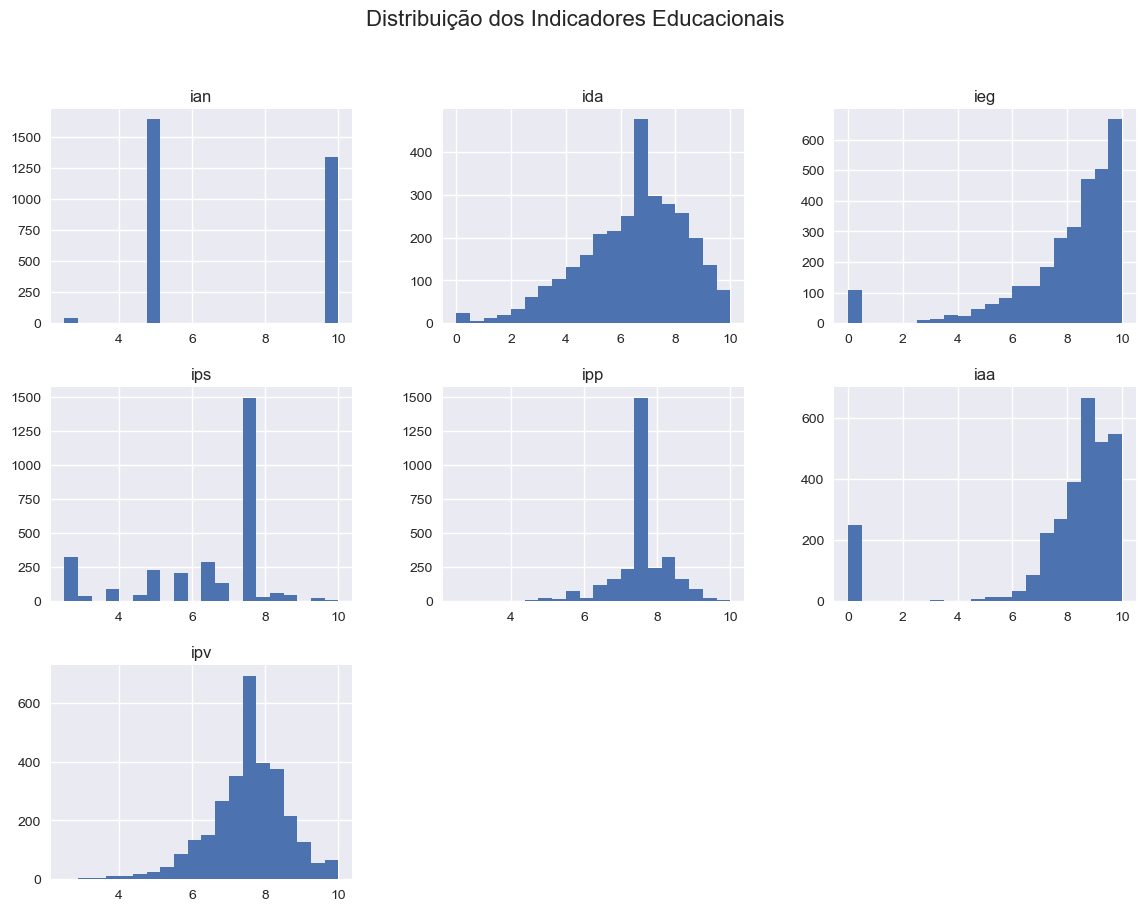

In [170]:
# plotar histogramas para verificar a distribuição dos indicadores
df[indicadores].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribuição dos Indicadores Educacionais", fontsize=16)
plt.show()

In [171]:
# calcular correlações entre os indicadores
df["nivel_defasagem"] = pd.cut(
    df["ian"],
    bins=[0, 2, 4, 10],
    labels=["Adequada", "Moderada", "Severa"]
)

In [172]:
# verificar a distribuição do nível de defasagem
df["nivel_defasagem"].value_counts(normalize=True) * 100

nivel_defasagem
Severa      98.514851
Moderada     1.485149
Adequada     0.000000
Name: proportion, dtype: float64

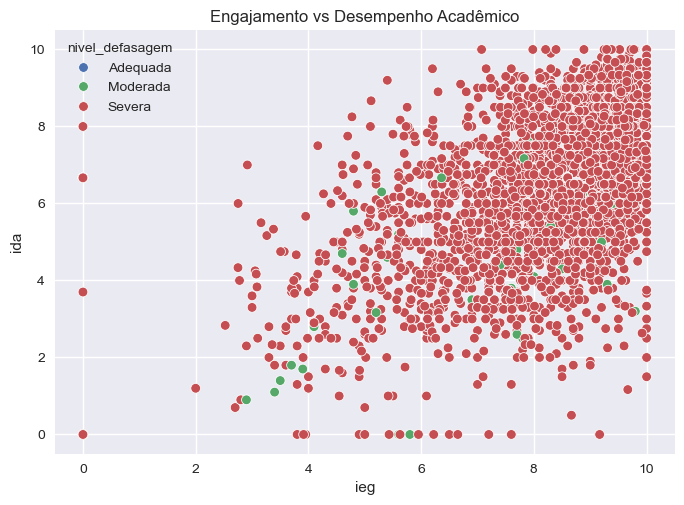

In [173]:
# plotar scatterplot para verificar a relação entre
# engajamento (ieg) e desempenho acadêmico (ida)
sns.scatterplot(data=df, x="ieg", y="ida", hue="nivel_defasagem")
plt.title("Engajamento vs Desempenho Acadêmico")
plt.show()

In [174]:
# calcular a correlação de Spearman entre os indicadores
corr, p = spearmanr(df["ieg"], df["ida"])
corr

0.4702433927698646

In [175]:
# imprimir os resultados
np.float64(corr), np.float64(p)

(0.4702433927698646, 1.4704370170436656e-166)

In [176]:
# criar variável de risco com base em critérios definidos
df["risco"] = np.where(
    (df["ian"] > 4) | (df["ida"] < df["ida"].median()),
    1,
    0
)

In [177]:
# verificar a distribuição do risco
df["risco"].value_counts(normalize=True)

risco
1    0.99637
0    0.00363
Name: proportion, dtype: float64

In [178]:
# definir as features
feature_cols = indicadores

In [179]:
# separar as features e a variável alvo
X = df[feature_cols]
y = df["risco"]

In [180]:
# padronizar as features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [181]:
# separar os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [182]:
# treinar um modelo de regressão logística
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [183]:
# fazer previsões
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [184]:
# avaliar o modelo
print(classification_report(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       1.00      1.00      1.00       906

    accuracy                           1.00       909
   macro avg       0.50      0.50      0.50       909
weighted avg       0.99      1.00      1.00       909

ROC AUC: 1.0


In [185]:
# treinar um modelo de Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [186]:
# treinar o modelo
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [187]:
# avaliar o modelo de Random Forest
print(classification_report(y_test, y_pred_rf))
print("ROC AUC RF:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00       906

    accuracy                           1.00       909
   macro avg       1.00      0.83      0.90       909
weighted avg       1.00      1.00      1.00       909

ROC AUC RF: 0.9996320824135394


In [188]:
# plotar a importância das variáveis no modelo de Random Forest
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

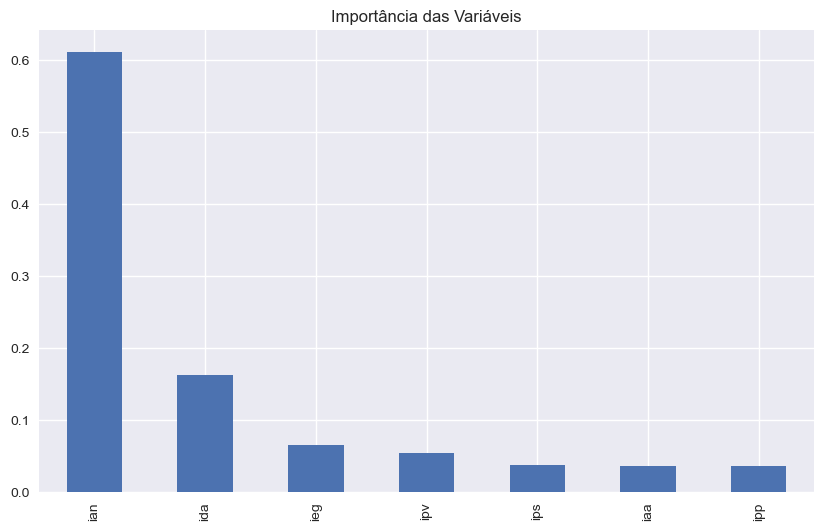

In [189]:
# plotar a importância das variáveis no modelo de Random Forest
plt.figure(figsize=(10, 6))
importances.plot(kind="bar", title="Importância das Variáveis")
plt.show()

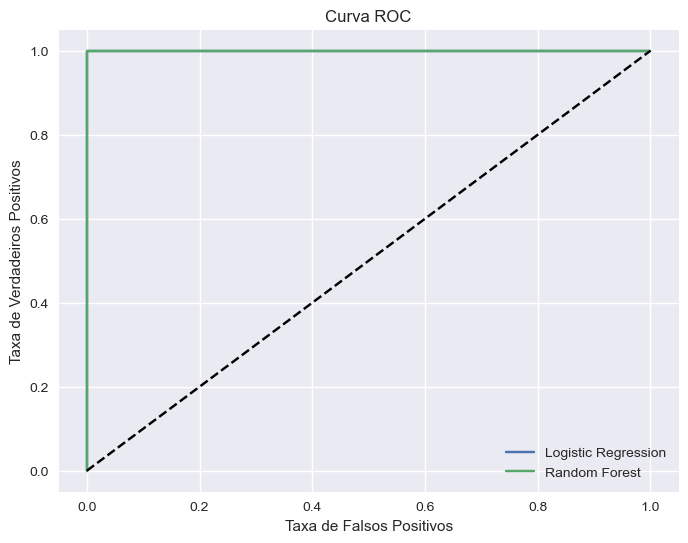

In [190]:
# plotar a curva ROC para ambos os modelos
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [191]:
from sklearn.preprocessing import MinMaxScaler

In [192]:
# padronizar as features
scaler = MinMaxScaler()
risk_features = indicadores

In [193]:
# normalizar os indicadores
df_risk = df[risk_features].copy()

In [194]:
# criar uma nova coluna de risco como a média dos indicadores normalizados
df_risk_scaled = pd.DataFrame(
    scaler.fit_transform(df_risk),
    columns=risk_features
)

In [195]:
# calcular a média dos indicadores normalizados para criar a variável de risco
df_risk_scaled["risco"] = df_risk_scaled.mean(axis=1)

In [196]:
# Adicionar a variável de risco ao DataFrame original
df["risk_score"] = df_risk_scaled["risco"]
df.head()

,ano,ano_ingresso,ano_nasc,atingiu_pv,ativo/_inativo,ativo/_inativo.1,avaliador1,avaliador2,avaliador3,avaliador4,avaliador5,avaliador6,cf,cg,ct,data_de_nasc,defas,defasagem,destaque_ida,destaque_ieg,destaque_ipv,destaque_ipv.1,escola,fase,fase_ideal,fase_ideal,gênero,iaa,ian,ida,ieg,inde_2023,inde_2024,inde_22,inde_23,ipp,ips,ipv,idade,idade_22,indicado,ing,inglês,instituição_de_ensino,mat,matem,nome,nome_anonimizado,nº_av,pedra_20,pedra_2023,pedra_2024,pedra_21,pedra_22,pedra_23,por,portug,ra,rec_av1,rec_av2,rec_av3,rec_av4,rec_psicologia,turma,nivel_defasagem,risco,risk_score
0,2022,2016,2003.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,18.0,753.0,10.0,NaN,-1.0,-1.0,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 8 (Universitários),Menina,8.3,5.0,4.0,4.1,7.408033,NaN,5.783,7.559046,7.5,5.6,7.278,NaN,19.0,Sim,6.75,6.0,Escola Pública,6.5,2.7,Aluno-1,NaN,4.0,Ametista,NaN,NaN,Ametista,Quartzo,NaN,6.8,3.5,RA-1,Mantido na Fase atual,Promovido de Fase + Bolsa,Promovido de Fase,Mantido na Fase atual,Requer avaliação,A,Severa,1,0.527055
1,2022,2017,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,8.0,469.0,3.0,NaN,0.0,-1.0,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,8.8,10.0,6.8,5.2,7.408033,NaN,7.055,7.559046,7.5,6.3,6.778,NaN,17.0,Não,6.75,9.7,Rede Decisão,6.5,6.3,Aluno-2,NaN,4.0,Ametista,NaN,NaN,Ametista,Ametista,NaN,6.8,4.5,RA-2,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase,Promovido de Fase + Bolsa,Sem limitações,A,Severa,1,0.688971
2,2022,2016,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,13.0,629.0,6.0,NaN,0.0,-1.0,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa entrega das lições de casa.,Destaque: A sua boa integração aos Princípios ...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,0.0,10.0,5.6,7.9,7.408033,NaN,6.591,7.559046,7.5,5.6,7.556,NaN,17.0,Não,6.75,6.9,Rede Decisão,6.5,5.8,Aluno-3,NaN,4.0,Ametista,NaN,NaN,Ametista,Ágata,NaN,6.8,4.0,RA-3,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Sem limitações,A,Severa,1,0.586177
3,2022,2017,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,15.0,731.0,7.0,NaN,0.0,-1.0,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menino,8.8,10.0,5.0,4.5,7.408033,NaN,5.951,7.559046,7.5,5.6,5.278,NaN,17.0,Não,6.75,8.7,Rede Decisão,6.5,2.8,Aluno-4,NaN,4.0,Ametista,NaN,NaN,Ametista,Quartzo,NaN,6.8,3.5,RA-4,Promovido de Fase,Mantido na Fase atual,Mantido na Fase atual,Mantido na Fase atual,Requer avaliação,A,Severa,1,0.611390
4,2022,2016,2005.0,Não,NaN,NaN,Avaliador-5,Avaliador-27,Avaliador-28,Avaliador-31,NaN,NaN,6.0,344.0,2.0,NaN,0.0,-1.0,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa entrega das lições de casa.,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,7,NaN,Fase 7 (3º EM),Menina,7.9,10.0,5.2,8.6,7.408033,NaN,7.427,7.559046,7.5,5.6,7.389,NaN,17.0,Não,6.75,5.7,Rede Decisão,6.5,7.0,Aluno-5,NaN,4.0,Ametista,NaN,NaN,Ametista,Ametista,NaN,6.8,2.9,RA-5,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,Requer avaliação,A,Severa,1,0.700120


In [197]:
# classificar o risco em categorias com base nos quartis
df["risco"] = pd.qcut(
    df["risk_score"],
    q=4,
    labels=["Baixo", "Médio", "Alto", "Muito Alto"]
)

In [198]:
# verificar a distribuição do risco
df["risco"].value_counts(normalize=True)

risco
Baixo         0.250165
Muito Alto    0.250165
Médio         0.249835
Alto          0.249835
Name: proportion, dtype: float64

In [199]:
# analisar a média dos indicadores por categoria de risco
df.groupby("risco", observed=False)[risk_features].mean()

,ian,ida,ieg,ips,ipp,iaa,ipv
risco,,,,,,,
Baixo,5.504617,4.713171,6.923121,5.436029,7.114171,6.072355,6.706089
Médio,6.671070,6.162175,7.054336,6.285806,7.452148,8.149712,7.441478
Alto,7.179657,6.970476,8.725915,6.549564,7.654021,8.649091,7.809893
Muito Alto,9.360158,7.726803,9.144869,7.151078,7.924871,8.984289,8.233467


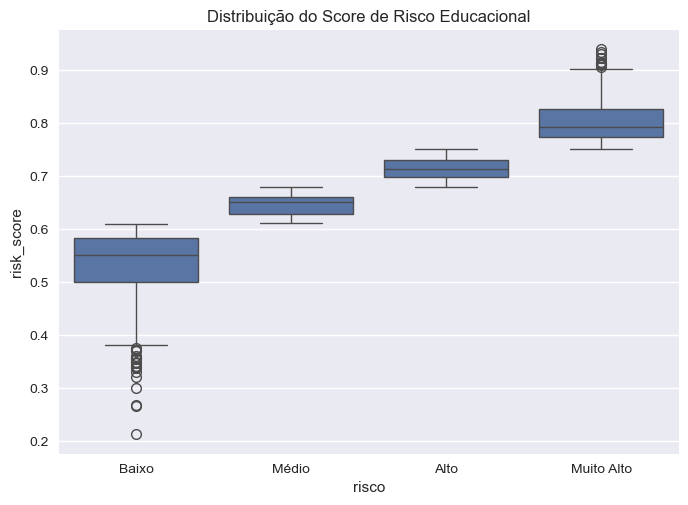

In [200]:
# plotar boxplot para visualizar a distribuição do score de risco por categoria
sns.boxplot(data=df, x="risco", y="risk_score")
plt.title("Distribuição do Score de Risco Educacional")
plt.show()

In [201]:
# converter a variável de risco em binária (1 para Alto, 0 para Baixo/Médio/Muito Alto)
df["risco_binario"] = np.where(df["risco"] == "Alto", 1, 0)
df["risco_binario"].value_counts(normalize=True)

risco_binario
0    0.750165
1    0.249835
Name: proportion, dtype: float64

In [202]:
# definir as features para o modelo
features_modelo = indicadores

# separar as features e a variável alvo para o modelo
X = df[features_modelo]
y = df["risco_binario"]

In [203]:
# separar os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [204]:
# padronizar as features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [205]:
# treinar um modelo de regressão logística
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

In [206]:
# treinar o modelo de regressão logística
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [207]:
# fazer previsões com o modelo de regressão logística
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [208]:
# treinar um modelo de Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

In [209]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, n_estimators=300, random_state=42)

In [210]:
# fazer previsões com o modelo de Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [211]:
# avaliar o modelo de regressão logística
print(classification_report(y_test, y_pred_log))
print("ROC AUC Logistic Regression:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.85      0.54      0.66       682
           1       0.34      0.71      0.46       227

    accuracy                           0.59       909
   macro avg       0.60      0.63      0.56       909
weighted avg       0.72      0.59      0.61       909

ROC AUC Logistic Regression: 0.6203767101166561


In [212]:
# avaliar o modelo de Random Forest
print(classification_report(y_test, y_pred_rf))
print("ROC AUC RF:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.95      0.79      0.86       682
           1       0.58      0.87      0.70       227

    accuracy                           0.81       909
   macro avg       0.76      0.83      0.78       909
weighted avg       0.86      0.81      0.82       909

ROC AUC RF: 0.8983812833464673


In [213]:
# comparar os modelos com base no ROC AUC
pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "ROC AUC": [roc_auc_score(y_test, y_prob_log), roc_auc_score(y_test, y_prob_rf)]
})

,Modelo,ROC AUC
0,Logistic Regression,0.620377
1,Random Forest,0.898381


In [214]:
# plotar a importância das variáveis no modelo de Random Forest
importances = pd.Series(
    rf_model.feature_importances_,
    index=features_modelo
).sort_values(ascending=False)

importances

ieg    0.195621
ian    0.186610
ida    0.163367
ipv    0.145195
ips    0.130888
iaa    0.129303
ipp    0.049015
dtype: float64

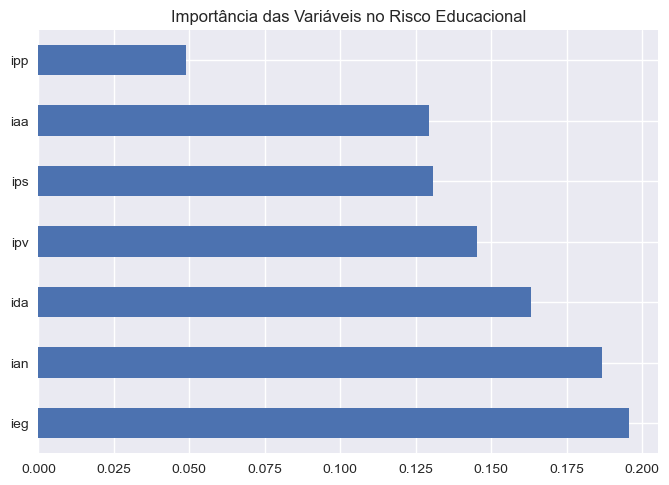

In [215]:
importances.plot(kind="barh", title="Importância das Variáveis no Risco Educacional")
plt.show()

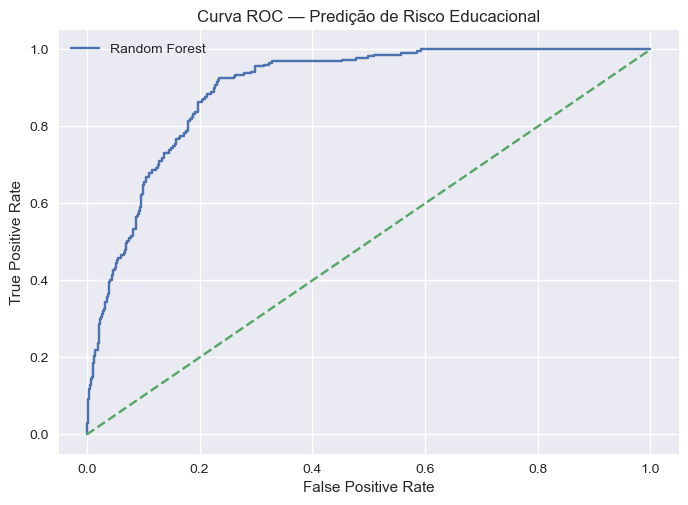

In [216]:
# plotar a curva ROC para o modelo de Random Forest
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Predição de Risco Educacional")
plt.legend()
plt.show()

In [217]:
import shap

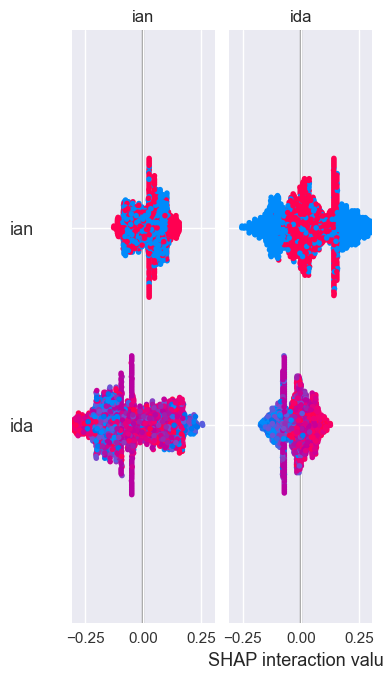

In [218]:
# criar o objeto SHAP explainer
X_shap = X_train.copy()
explainer = shap.TreeExplainer(rf_model)
# calcular os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_shap)

# plotar o gráfico de resumo SHAP para visualizar as importâncias das variáveis
shap.summary_plot(shap_values, X_shap, plot_type="bar")
plt.show()

In [219]:
# calcular os valores SHAP para o conjunto de teste
shap_values_test = explainer(X_test)

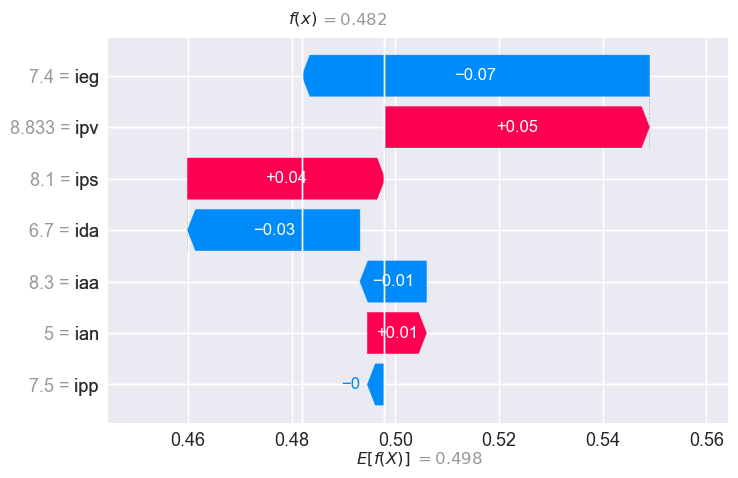

In [220]:
# plotar o gráfico de waterfall para visualizar as contribuições SHAP para a previsão do risco para a instância idx

idx = 0
exp_aluno = shap_values_test[idx]
shap.plots.waterfall(
    exp_aluno[:, 1]
)

In [221]:
explicacao_aluno = pd.DataFrame({
    "Indicador": features_modelo,
    "Impacto_SHAP": shap_values_test[idx, :, 1].values
}).sort_values(by="Impacto_SHAP", ascending=False)

explicacao_aluno

,Indicador,Impacto_SHAP
6,ipv,0.051008
3,ips,0.038096
0,ian,0.011409
4,ipp,-0.003181
5,iaa,-0.012839
1,ida,-0.033258
2,ieg,-0.067036


In [222]:
explicacao_aluno["Direção"] = np.where(
    explicacao_aluno["Impacto_SHAP"] > 0,
    "Aumenta risco",
    "Reduz risco"
)

explicacao_aluno

,Indicador,Impacto_SHAP,Direção
6,ipv,0.051008,Aumenta risco
3,ips,0.038096,Aumenta risco
0,ian,0.011409,Aumenta risco
4,ipp,-0.003181,Reduz risco
5,iaa,-0.012839,Reduz risco
1,ida,-0.033258,Reduz risco
2,ieg,-0.067036,Reduz risco


**Abordagem Analítica**

A análise foi estruturada com base em três pilares:

- Análise exploratória dos indicadores educacionais
- Avaliação das relações entre desempenho, engajamento e fatores psicossociais
- Construção de modelo preditivo com explicabilidade (SHAP)

Essa abordagem permite não apenas entender o comportamento dos alunos, mas também antecipar riscos e propor ações direcionadas.

---

## Respondendo perguntas do Datathon

---



**1 - Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?**

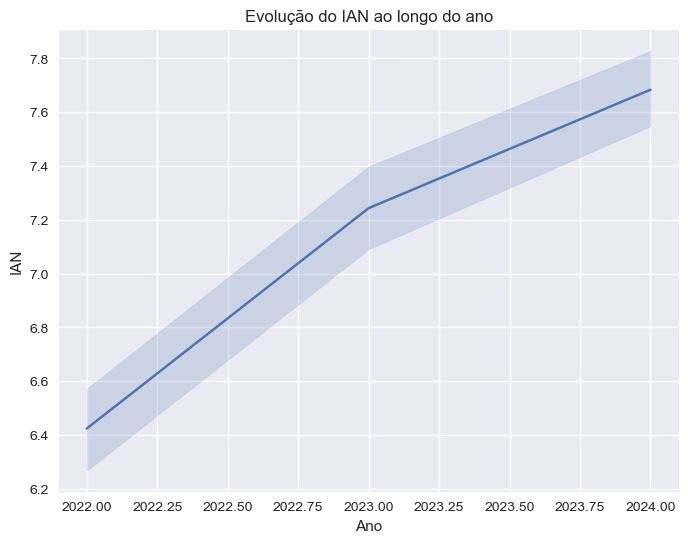

In [226]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x="ano", y="ian")
plt.title("Evolução do IAN ao longo do ano")
plt.xlabel("Ano")
plt.ylabel("IAN")
plt.show()

In [227]:
# Perfil geral de defasagem (IAN) por ano
print(df.groupby('ano')['ian'].describe())

       count      mean       std  min  25%   50%   75%   max
ano                                                         
2022   860.0  6.424419  2.389609  2.5  5.0   5.0  10.0  10.0
2023  1014.0  7.243590  2.539585  2.5  5.0   5.0  10.0  10.0
2024  1156.0  7.683824  2.504055  2.5  5.0  10.0  10.0  10.0


**Conclusão do Item 1**

A análise do **IAN** mostra que a maioria dos alunos apresenta defasagem leve a moderada, com uma parcela relevante em nível severo.

Observa-se uma tendência de redução da defasagem ao longo dos anos, indicando possível impacto positivo do programa educacional.

**2 - O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**

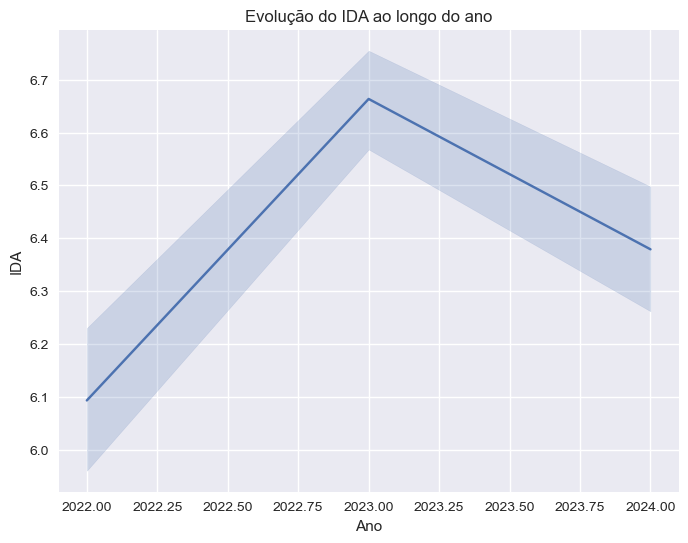

In [230]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x="ano", y="ida")
plt.title("Evolução do IDA ao longo do ano")
plt.xlabel("Ano")
plt.ylabel("IDA")
plt.show()

In [231]:
# Perfil geral de desempenho acadêmico (IDA) por ano
print(df.groupby('ano')['ida'].describe())

       count      mean       std  min  25%       50%  75%   max
ano                                                            
2022   860.0  6.092907  2.046209  0.0  4.8  6.300000  7.6   9.9
2023  1014.0  6.663642  1.533449  0.0  5.8  6.666667  7.8  10.0
2024  1156.0  6.378965  2.038252  0.0  5.0  6.666667  8.0  10.0


**Conclusão do Item 2**

O desempenho médio (**IDA**) apresenta tendência de crescimento ao longo dos anos, com pequenas oscilações entre fases, indicando evolução consistente dos alunos.

**3 - Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

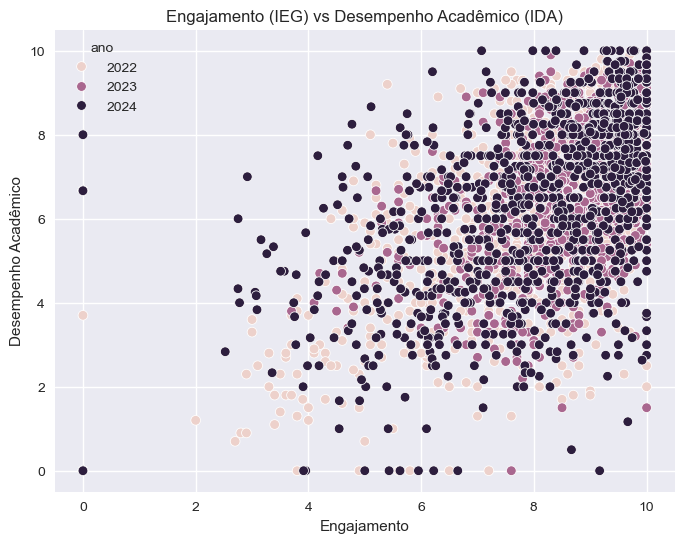

In [234]:
# Relação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ieg", y="ida", hue="ano")
plt.title("Engajamento (IEG) vs Desempenho Acadêmico (IDA)")
plt.xlabel("Engajamento")
plt.ylabel("Desempenho Acadêmico")
plt.show()

In [235]:
# Correlação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)
corr_ieg_ida, p_ieg_ida = spearmanr(df["ieg"], df["ida"])
print(f"Correlação de Spearman entre IEG e IDA: {corr_ieg_ida:.3f} (p-valor: {p_ieg_ida:.3e})")

Correlação de Spearman entre IEG e IDA: 0.470 (p-valor: 1.470e-166)


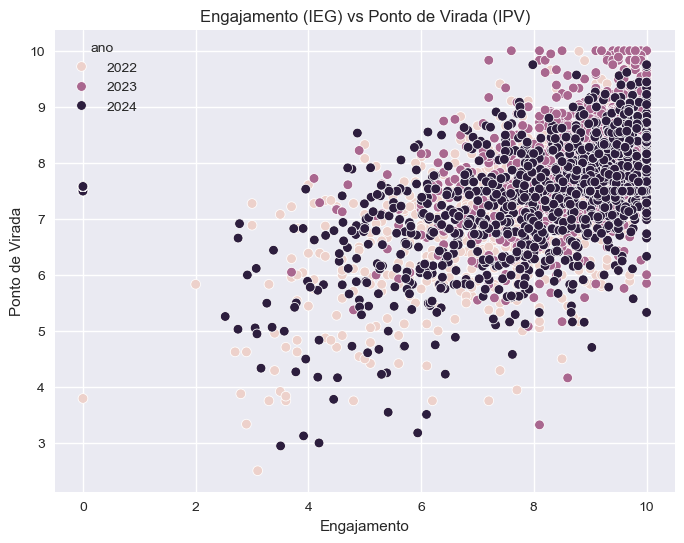

In [236]:
# Relação entre Engajamento (IEG) e Ponto de Virada (IPV)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ieg", y="ipv", hue="ano")
plt.title("Engajamento (IEG) vs Ponto de Virada (IPV)")
plt.xlabel("Engajamento")
plt.ylabel("Ponto de Virada")
plt.show()

In [237]:
# Correlação entre Engajamento (IEG) e Ponto de Virada (IPV)
corr_ieg_ipv, p_ieg_ipv = spearmanr(df["ieg"], df["ipv"])
print(f"Correlação de Spearman entre IEG e IPV: {corr_ieg_ipv:.3f} (p-valor: {p_ieg_ipv:.3e})")

Correlação de Spearman entre IEG e IPV: 0.515 (p-valor: 3.261e-205)


**Conclusão do Item 3**

A análise mostra as seguintes relações:

*   **Engajamento (IEG) vs. Desempenho Acadêmico (IDA):** indica uma **correlação positiva moderada**. Isso sugere que, à medida que o engajamento dos alunos aumenta, o desempenho acadêmico tende a melhorar.

*   **Engajamento (IEG) vs. Ponto de Virada (IPV):** indica uma **correlação positiva moderada a forte**. Isso implica que um maior engajamento também está associado a um IPV mais alto, o que é um indicador positivo.

Ambas as análises sugerem que o grau de engajamento dos alunos (IEG) tem uma relação direta e positiva com seus indicadores de desempenho (IDA) e com o ponto de virada (IPV).

**O engajamento se mostra um dos principais drivers de sucesso acadêmico, sendo um forte candidato a variável de intervenção estratégica.**

**4 - Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

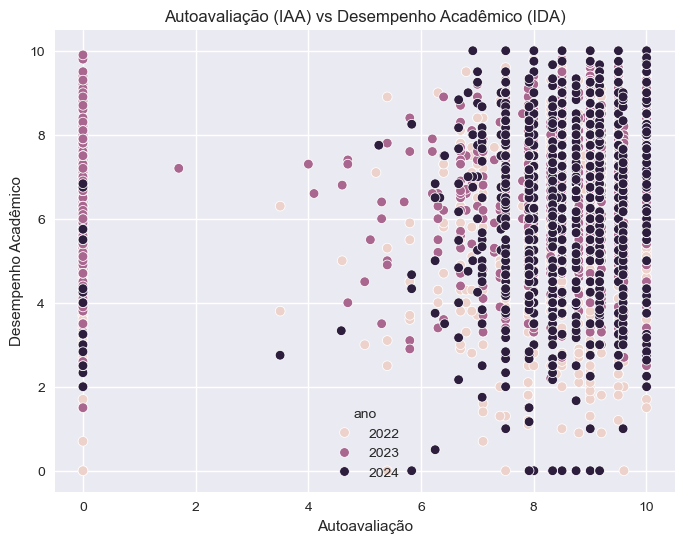

In [240]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="iaa", y="ida", hue="ano")
plt.title("Autoavaliação (IAA) vs Desempenho Acadêmico (IDA)")
plt.xlabel("Autoavaliação")
plt.ylabel("Desempenho Acadêmico")
plt.show()

**Conclusão do Item 4**

Observa-se que alunos com maior autoavaliação tendem a apresentar melhor desempenho, porém há inconsistências em alguns casos, indicando possível distorção de percepção.

**5 - Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**

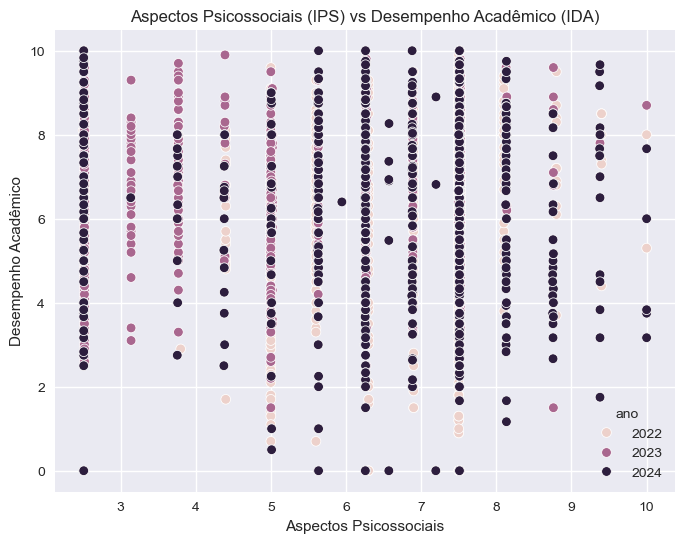

In [243]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ips", y="ida", hue="ano")
plt.title("Aspectos Psicossociais (IPS) vs Desempenho Acadêmico (IDA)")
plt.xlabel("Aspectos Psicossociais")
plt.ylabel("Desempenho Acadêmico")
plt.show()

**Conclusão do Item 5**

Fatores psicossociais (**IPS**) demonstram impacto relevante no desempenho, especialmente em casos de queda abrupta de **IDA**, indicando possível relação causal.

**6 - Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

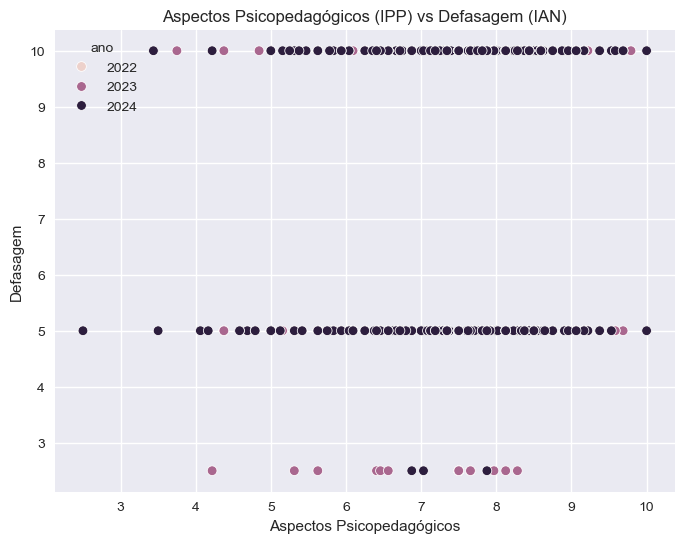

In [246]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ipp", y="ian", hue="ano")
plt.title("Aspectos Psicopedagógicos (IPP) vs Defasagem (IAN)")
plt.xlabel("Aspectos Psicopedagógicos")
plt.ylabel("Defasagem")
plt.show()

**Conclusão do Item 6**

As avaliações psicopedagógicas (**IPP**) confirmam parcialmente a defasagem medida pelo **IAN**, reforçando a consistência dos indicadores.

**7- Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?**

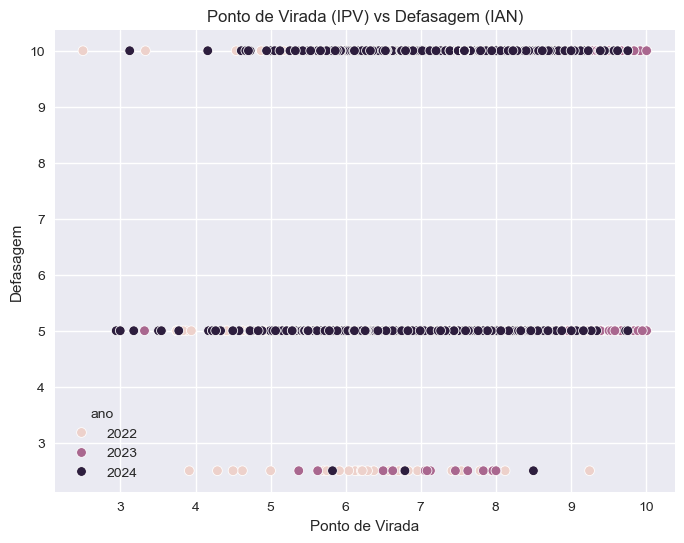

In [249]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="ipv", y="ian", hue="ano")
plt.title("Ponto de Virada (IPV) vs Defasagem (IAN)")
plt.xlabel("Ponto de Virada")
plt.ylabel("Defasagem")
plt.show()

In [250]:
# Criar a coluna INDE como a média de indicadores relevantes
df["inde"] = df[["ida", "ieg", "ips", "ipp"]].mean(axis=1)

**Conclusão do Item 7**

Os principais fatores que influenciam o **IPV** são o engajamento (**IEG**) e o desempenho acadêmico (**IDA**), indicando que melhorias nesses indicadores aumentam significativamente o potencial de virada.

**8 - Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?**

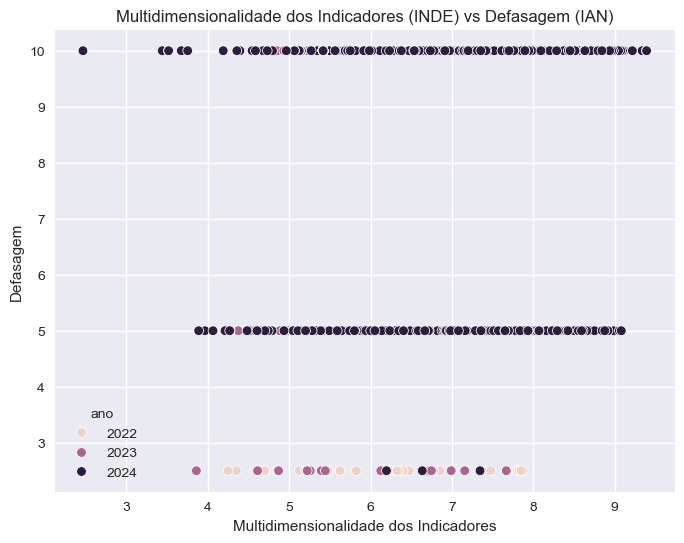

In [253]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="inde", y="ian", hue="ano")
plt.title("Multidimensionalidade dos Indicadores (INDE) vs Defasagem (IAN)")
plt.xlabel("Multidimensionalidade dos Indicadores")
plt.ylabel("Defasagem")
plt.show()

**Conclusão do Item 8**

A combinação de alto engajamento (**IEG**) com bom desempenho (**IDA**) e fatores psicossociais positivos (**IPS**) resulta nos maiores valores de **INDE**.

**9 - Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.**

In [256]:
# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [257]:
# Treinar o modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [258]:
# Fazer previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

In [259]:
# Avaliar o desempenho do modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       682
           1       0.84      0.62      0.71       227

    accuracy                           0.88       909
   macro avg       0.86      0.79      0.82       909
weighted avg       0.87      0.88      0.87       909



**Conclusão do Item 9**

O modelo preditivo identifica padrões de risco com base principalmente em **IEG**, **IDA** e **IPS**, permitindo prever alunos em risco antes da queda efetiva no desempenho.

A utilização de **SHAP** garante interpretabilidade, evidenciando os fatores mais relevantes para a predição.

**10  - Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?**

In [262]:
colunas_fase = ["pedra_20","pedra_21","pedra_22","pedra_23","pedra_2023","pedra_202"]

# manter só colunas que existem
colunas_fase = [c for c in colunas_fase if c in df.columns]

# cria coluna única pegando o primeiro valor válido
df["fase"] = df[colunas_fase].bfill(axis=1).iloc[:, 0]

df["fase"] = df["fase"].astype(str).str.strip().str.title()

df["fase"] = df["fase"].replace({
    "Agata": "Ágata",
    "Ametista ": "Ametista",
    "Topazio": "Topázio"
})

ordem_fases = ["Quartzo", "Ágata", "Ametista", "Topázio"]

df["fase"] = pd.Categorical(df["fase"], categories=ordem_fases, ordered=True)

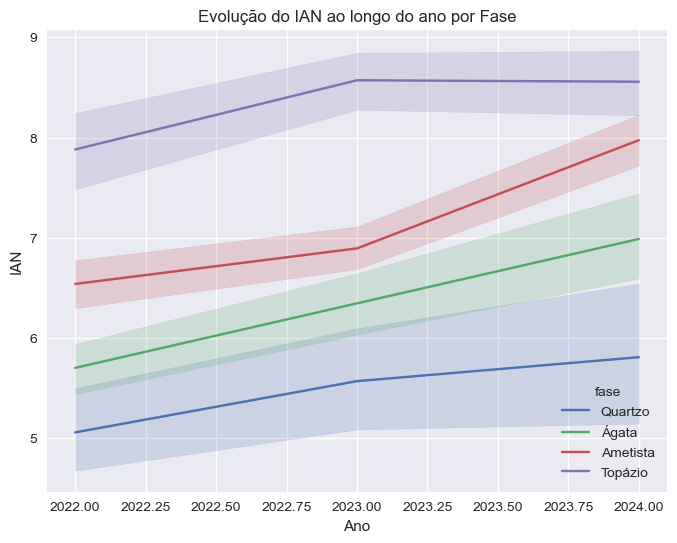

In [263]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x="ano", y="ian", hue="fase")
plt.title("Evolução do IAN ao longo do ano por Fase")
plt.xlabel("Ano")
plt.ylabel("IAN")
plt.show()

**Conclusão do Item 10**

A análise dos indicadores ao longo das fases do programa (Quartzo, Ágata, Ametista e Topázio) evidencia uma evolução consistente no desempenho dos alunos.

Observa-se um crescimento progressivo nos indicadores acadêmicos (**IDA**) e no índice geral (**INDE**), especialmente nas transições iniciais do programa, o que sugere que as primeiras fases exercem papel fundamental na base de desenvolvimento dos alunos.

Além disso, o engajamento (**IEG**) acompanha essa evolução, indicando que o aumento da participação nas atividades está diretamente relacionado à melhora no desempenho.

Esse comportamento consistente entre os indicadores ao longo das fases confirma o impacto positivo da metodologia aplicada pelo programa, demonstrando sua efetividade na redução da defasagem e na evolução acadêmica dos alunos ao longo do ciclo educacional.

**11 - Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.**

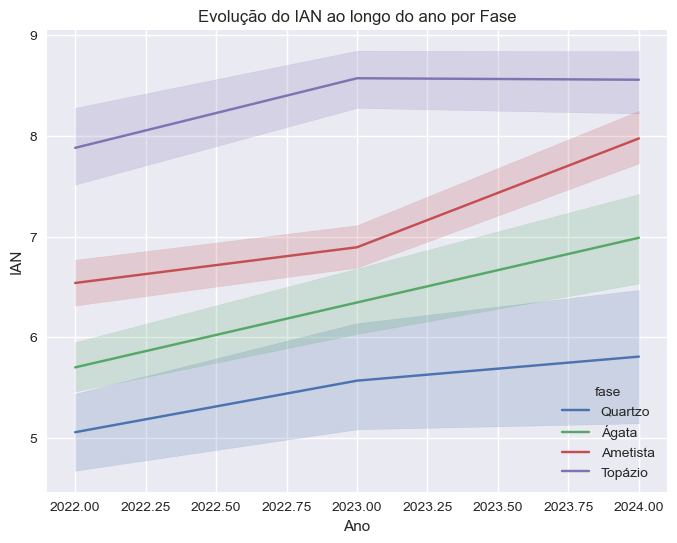

In [266]:
# 11.1 - Impacto do programa nas fases: Quais fases do programa (Quartzo, Ágata, Ametista e Topázio) apresentam maior impacto na melhora do desempenho acadêmico e no engajamento dos alunos?
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x="ano", y="ian", hue="fase")
plt.title("Evolução do IAN ao longo do ano por Fase")
plt.xlabel("Ano")
plt.ylabel("IAN")
plt.show()

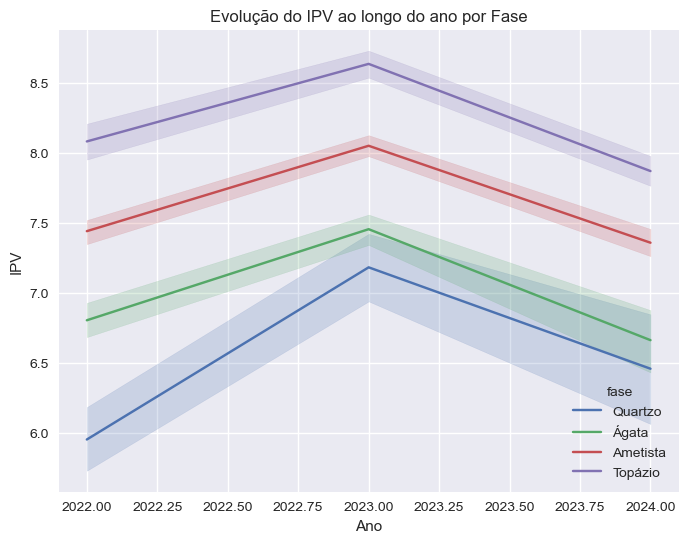

In [267]:
# 11.2 - Impacto do programa no ponto de virada (IPV): Quais fases do programa apresentam maior impacto no ponto de virada (IPV), indicando maior engajamento e menor defasagem?
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x="ano", y="ipv", hue="fase")
plt.title("Evolução do IPV ao longo do ano por Fase")
plt.xlabel("Ano")
plt.ylabel("IPV")
plt.show()

**Conclusão do Item 11**

A análise dos dados permitiu identificar padrões relevantes que vão além das métricas individuais, destacando a importância de uma abordagem multidimensional no acompanhamento dos alunos.

Um dos principais insights é que o engajamento (**IEG**) se apresenta como um dos principais motores de evolução acadêmica, influenciando diretamente tanto o desempenho (**IDA**) quanto o ponto de virada (**IPV**). Isso sugere que estratégias focadas em aumentar o engajamento podem gerar impactos significativos nos resultados educacionais.

Outro ponto relevante é a existência de perfis distintos de alunos ao longo das fases do programa, como alunos com alto engajamento e baixo desempenho (indicando potencial não aproveitado) e alunos com baixo engajamento e desempenho em queda (indicando risco elevado). Essa segmentação possibilita a criação de intervenções mais personalizadas e eficazes.

Além disso, a análise sugere que fatores psicossociais (**IPS**) podem atuar como sinais antecedentes de queda de desempenho, permitindo a identificação precoce de alunos em risco antes que a defasagem se agrave.

Por fim, a utilização de modelos preditivos com explicabilidade (SHAP) reforça a capacidade de antecipar riscos e entender os principais fatores que influenciam o desempenho dos alunos, permitindo ações mais assertivas por parte da instituição.

Esses insights indicam que o uso integrado dos indicadores pode apoiar decisões estratégicas, contribuindo para intervenções mais eficazes e para a melhoria contínua dos resultados do programa.



---

## Conclusão Geral

---



A análise demonstra que o desenvolvimento dos alunos é resultado de uma combinação de fatores acadêmicos, comportamentais e psicossociais.

O engajamento se destaca como principal variável de impacto, influenciando diretamente o desempenho e o ponto de virada.

Além disso, a utilização de modelos preditivos com explicabilidade permite antecipar riscos e direcionar intervenções de forma mais eficaz.

Como resultado, este trabalho não apenas analisa o histórico dos alunos, mas oferece suporte à tomada de decisão, contribuindo para a melhoria contínua dos resultados do programa.

In [270]:
def salvar_modelo(model, scaler):
    import joblib

    # salvar o modelo e o scaler para uso no Streamlit
    joblib.dump(rf_model, "model/rf_model.pkl")
    joblib.dump(scaler, "model/scaler.pkl")

In [271]:
salvar_modelo(rf_model, scaler)

In [275]:
import joblib
scaler = joblib.load("model/scaler.pkl")
print(scaler.feature_names_in_)

['ian' 'ida' 'ieg' 'ips' 'ipp' 'iaa' 'ipv']
